Import libraries and name csv file.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#to get rid of scientific notation
pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


Convert date into a data type, then visualizing the data and plotting it to find numeric correlations

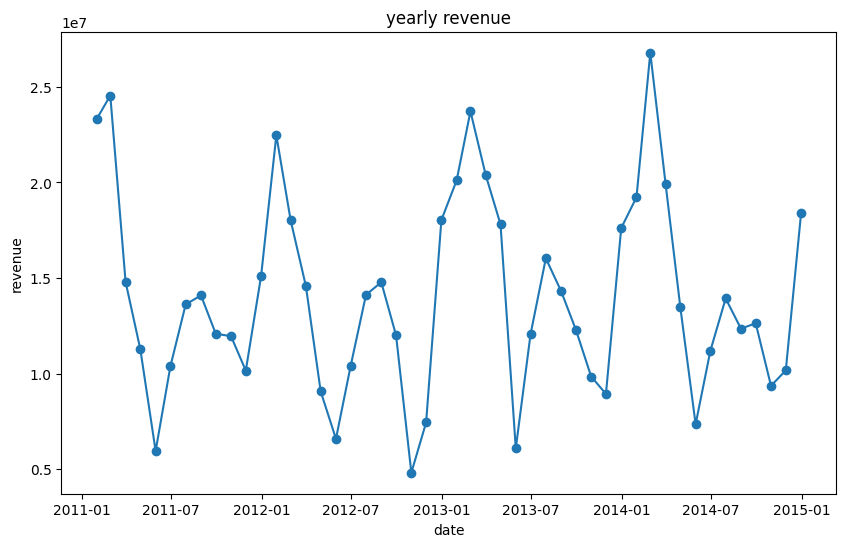

In [ ]:
HS_data['date'] = pd.to_datetime(HS_data['date'])
plt.figure(figsize=(10,6))

plt.title('yearly revenue')

plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(HS_data['date'], HS_data['revenue'], marker='o')

Analyze numeric relationships between variables

In [ ]:
HS_data.loc[:,['revenue','production','coolDD','heatDD']].corr()

,revenue,production,coolDD,heatDD
revenue,1.00,0.63,-0.17,0.69
production,0.63,1.00,0.51,0.03
coolDD,-0.17,0.51,1.00,-0.72
heatDD,0.69,0.03,-0.72,1.00


Seperate data into training and testing

In [ ]:
dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

Prepare independent and dependent variables of our first model

In [ ]:
import statsmodels.api as sm
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:,'production']
x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()

model1.params

,0
const,4897663.26
production,18.99


# revenue = 18.99 * production + 4897663.26


prepare the testing version of the independent variable and add the constant, then use our model to predict future values

In [ ]:
x_test = dt4testing.loc[:,'production']
x_test = sm.add_constant(x_test)
display(model1.predict(x_test))
display(HS_data)

,0
36,16414428.69
37,18460401.82
38,20197640.55
39,12035930.72
40,10202060.55
41,14727936.65
42,19131656.04
43,17497582.00
44,18223533.25
45,12717212.73


,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


Compare the predicted numbers vs actual numbers from the testing data. Copy testing data to new data frame, add a column with our predicted revenue numbers, then find the percentage error at each row.

In [ ]:
model1_assessment = dt4testing.copy()
model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)
model1_assessment['percentage_error'] = abs((model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue']
                                             )/ model1_assessment['revenue'])

display(model1_assessment)

,type,date,revenue,production,coolDD,heatDD,model1_predicted_revenue,percentage_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,16414428.69,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,18460401.82,0.31
38,dt4testing,2014-03-31,19935840,805600,0,866,20197640.55,0.01
39,dt4testing,2014-04-30,13468000,375856,0,412,12035930.72,0.11
40,dt4testing,2014-05-31,7344128,279296,49,88,10202060.55,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,14727936.65,0.32
42,dt4testing,2014-07-31,13929472,749472,380,0,19131656.04,0.37
43,dt4testing,2014-08-31,12352176,663432,322,0,17497582.00,0.42
44,dt4testing,2014-09-30,12628944,701656,178,14,18223533.25,0.44
45,dt4testing,2014-10-31,9361000,411728,24,166,12717212.73,0.36


Calculate the mean of percentage error (MAPE)

In [ ]:
model1_assessment['percentage_error'].mean()

np.float64(0.2542315606071484)

Visualize actual vs predicted

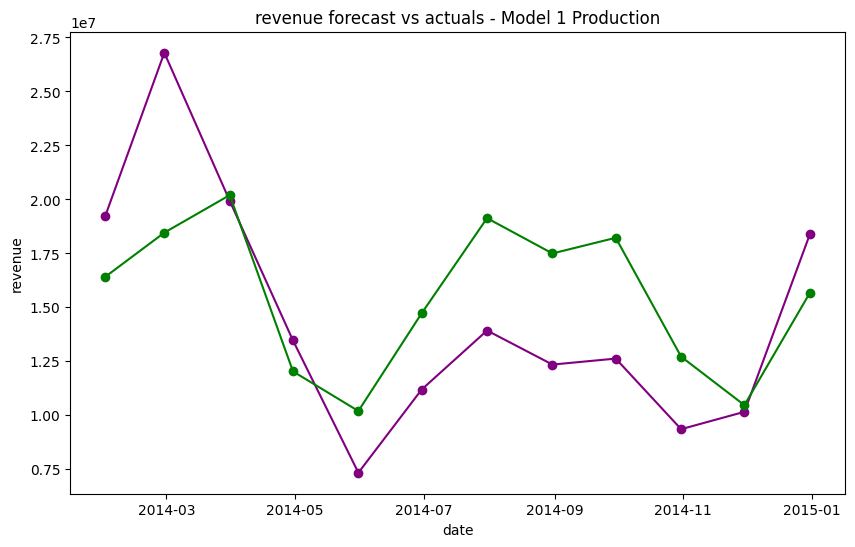

In [ ]:
plt.figure(figsize=(10,6))

plt.title('revenue forecast vs actuals - Model 1 Production')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1_assessment['date'],model1_assessment['revenue'],marker='o', color='purple')
plt.plot(model1_assessment['date'],model1_assessment['model1_predicted_revenue'],marker ='o', color='green')

##Repeat steps but create model for revenue and heatDD

In [ ]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:,'heatDD']
x = sm.add_constant(x)

model2 = sm.OLS(y,x).fit()

model2.params

,0
const,10333861.28
heatDD,9991.26


In [ ]:
x_test2 = dt4testing.loc[:,'heatDD']
x_test2 = sm.add_constant(x_test2)
display(model2.predict(x_test2))
display(HS_data)

,0
36,21554043.42
37,19705660.79
38,18986290.25
39,14450259.35
40,11213091.93
41,10333861.28
42,10333861.28
43,10333861.28
44,10473738.88
45,11992410.02


,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [ ]:
model2_assessment = dt4testing.copy()

model2_assessment['model2_predicted_revenue'] = model2.predict(x_test2)

model2_assessment['percentage_error'] = abs((model2_assessment['revenue'] - model2_assessment['model2_predicted_revenue']
                                             )/ model2_assessment['revenue'])

display(model2_assessment)

,type,date,revenue,production,coolDD,heatDD,model2_predicted_revenue,percentage_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,21554043.42,0.12
37,dt4testing,2014-02-28,26792280,714128,0,938,19705660.79,0.26
38,dt4testing,2014-03-31,19935840,805600,0,866,18986290.25,0.05
39,dt4testing,2014-04-30,13468000,375856,0,412,14450259.35,0.07
40,dt4testing,2014-05-31,7344128,279296,49,88,11213091.93,0.53
41,dt4testing,2014-06-30,11196216,517600,230,0,10333861.28,0.08
42,dt4testing,2014-07-31,13929472,749472,380,0,10333861.28,0.26
43,dt4testing,2014-08-31,12352176,663432,322,0,10333861.28,0.16
44,dt4testing,2014-09-30,12628944,701656,178,14,10473738.88,0.17
45,dt4testing,2014-10-31,9361000,411728,24,166,11992410.02,0.28


In [ ]:
model2_assessment['percentage_error'].mean()

np.float64(0.21648503280089135)

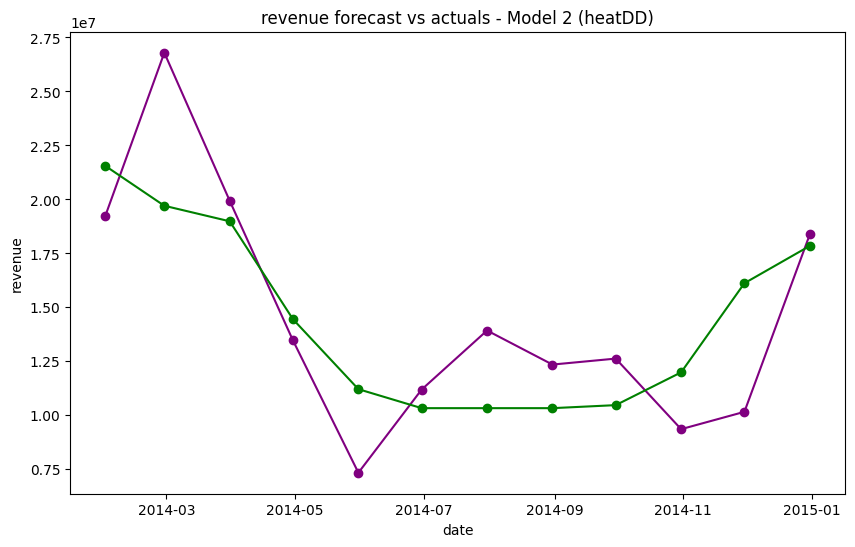

In [ ]:
plt.figure(figsize=(10,6))

plt.title('revenue forecast vs actuals - Model 2 (heatDD)')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model2_assessment['date'],model2_assessment['revenue'],marker='o', color='purple')
plt.plot(model2_assessment['date'],model2_assessment['model2_predicted_revenue'],marker ='o', color='green')

Compare both models against testing data

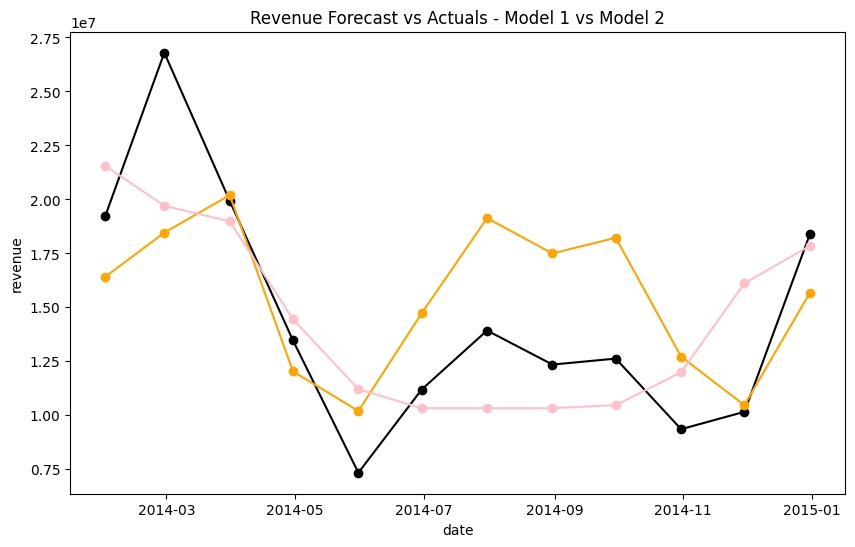

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Revenue Forecast vs Actuals - Model 1 vs Model 2')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1_assessment['date'], model1_assessment['revenue'], marker='o', color='black')
plt.plot(model1_assessment['date'], model1_assessment['model1_predicted_revenue'], marker='o', color='orange')
plt.plot(model2_assessment['date'], model2_assessment['model2_predicted_revenue'], marker='o', color='pink')


The two prepared models highlight and forecast monthly revenue for Hotazel Steam. Model 1 analyzes revenue based on production, while model 2 analyzes revenue based on heatDD. After conducting our analysis, model 1 produced a MAPE score of about 25.4%, while model 2 produced a MAPE score of about 21.6% This shows that model 2 is the stronger of the two models, as it has a lower average percentage error. We recommend that Hotazel Steam adopts this model.